In [351]:
pip install resampy

In [352]:
from google.colab import drive
drive.mount('/content/drive')

import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [353]:
print(os.getcwd())

/content


In [354]:
data_path = '/content/drive/'
print(os.listdir(data_path))

['.shortcut-targets-by-id', 'Shareddrives', 'MyDrive', '.Trash-0']


In [355]:
filelist = os.listdir(data_path)

for filename in filelist:
  print(filename)

.shortcut-targets-by-id
Shareddrives
MyDrive
.Trash-0


In [356]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from tensorflow.keras.utils import to_categorical
#from sklearn.model_selection import train_test_split

In [357]:
from pickle import dump
from pickle import load

In [358]:
train_data = '/content/extracted_data/train'
os.listdir(train_data)

['a_00000040_0.wav',
 'n_00000097_0.wav',
 'n_00000282_5000.wav',
 'n_00000003_0.wav',
 'a_00000084_0.wav',
 'n_00000022_0.wav',
 'a_00000061_0.wav',
 'n_00000038_0.wav',
 'n_00000106_5000.wav',
 'n_00000153_5000.wav',
 'n_00000121_0.wav',
 'n_00000245_0.wav',
 'n_00000354_0.wav',
 'n_00000169_5000.wav',
 'n_00000236_0.wav',
 'a_00000002_0.wav',
 'n_00000271_0.wav',
 'n_00000287_0.wav',
 'a_00000081_5000.wav',
 'n_00000011_5000.wav',
 'a_00000136_0.wav',
 'a_00000043_5000.wav',
 'n_00000260_0.wav',
 'n_00000155_5000.wav',
 'n_00000231_5000.wav',
 'n_00000151_0.wav',
 'n_00000123_0.wav',
 'n_00000196_0.wav',
 'n_00000036_5000.wav',
 'n_00000207_5000.wav',
 'n_00000332_5000.wav',
 'n_00000298_0.wav',
 'n_00000347_5000.wav',
 'a_00000093_0.wav',
 'n_00000078_0.wav',
 'n_00000182_5000.wav',
 'n_00000188_5000.wav',
 'n_00000358_0.wav',
 'a_00000129_0.wav',
 'a_00000059_5000.wav',
 'n_00000297_0.wav',
 'n_00000235_0.wav',
 'a_00000089_0.wav',
 'a_00000037_5000.wav',
 'n_00000154_0.wav',
 'n_

In [359]:
import os

data_path = "/content/drive/MyDrive/voice/unzip"  # path โฟลเดอร์หลัก
val_data = os.path.join(data_path, "val")          # path โฟลเดอร์ val

# แสดงไฟล์ใน val
print(os.listdir(val_data))


['a_00000079_0.wav', 'a_00000082_0.wav', 'a_00000135_5000.wav', 'a_00000102_5000.wav', 'a_00000088_0.wav', 'a_00000035_5000.wav', 'a_00000036_0.wav', 'a_00000058_0.wav', 'a_00000116_0.wav', 'a_00000093_5000.wav', 'a_00000130_5000.wav', 'a_00000042_5000.wav', 'a_00000115_5000.wav', 'a_00000129_5000.wav', 'a_00000072_0.wav', 'a_00000125_0.wav', 'a_00000106_5000.wav', 'a_00000064_5000.wav', 'a_00000047_5000.wav', 'a_00000063_0.wav', 'a_00000041_5000.wav', 'a_00000045_0.wav', 'a_00000100_5000.wav', 'a_00000123_5000.wav', 'a_00000114_0.wav', 'a_00000120_0.wav', 'a_00000062_0.wav', 'a_00000096_5000.wav', 'a_00000074_5000.wav', 'a_00000007_0.wav', 'a_00000016_0.wav', 'a_00000022_0.wav', 'a_00000018_5000.wav', 'a_00000031_5000.wav', 'a_00000032_5000.wav', 'a_00000028_5000.wav', 'a_00000024_0.wav', 'a_00000008_5000.wav', 'a_00000012_0.wav', 'a_00000003_0.wav', 'a_00000117_5000.wav', 'a_00000001_0.wav', 'a_00000031_0.wav', 'n_00000372_5000.wav', 'a_00000053_0.wav', 'n_00000371_5000.wav', 'n_0000

In [360]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [361]:
normal_train

'/content/extracted_data/train/n_*.wav'

In [362]:
normal_val = val_data+"/n_*.wav"
abnormal_val = val_data+"/a_*.wav"

In [363]:
import librosa
import librosa.display

In [364]:
import glob

normal_train_signals = [
    librosa.load(p)[0] for p in glob.glob(normal_train)
]

abnormal_train_signals = [
    librosa.load(p)[0] for p in glob.glob(abnormal_train)
]

normal_val_signals = [
    librosa.load(p)[0] for p in glob.glob(normal_val)
]

abnormal_val_signals = [
    librosa.load(p)[0] for p in glob.glob(abnormal_val)
]

In [365]:
print("Shape of normal_train_signals:", np.array(normal_train_signals, dtype=object).shape)
print("Shape of abnormal_train_signals:", np.array(abnormal_train_signals, dtype=object).shape)
print("Shape of normal_val_signals:", np.array(normal_val_signals, dtype=object).shape)
print("Shape of abnormal_val_signals:", np.array(abnormal_val_signals, dtype=object).shape)

Shape of normal_train_signals: (489, 110250)
Shape of abnormal_train_signals: (175, 110250)
Shape of normal_val_signals: (119, 110250)
Shape of abnormal_val_signals: (47, 110250)


In [366]:
def save_dataset(dataset, filename):
    dump(dataset, open(filename, 'wb'))
    print('Saved: %s' % filename)

In [367]:
datasetFile = 'coffee_train.pkl'
save_dataset([normal_train_signals, abnormal_train_signals], datasetFile)

Saved: coffee_train.pkl


In [368]:
datasetFile_val = 'coffee_val.pkl'
save_dataset([normal_val_signals, abnormal_val_signals], datasetFile_val)

Saved: coffee_val.pkl


In [369]:
def load_dataset(filename):
    return load(open(filename, 'rb'))

[normal_train_signals, abnormal_train_signals] = load_dataset(datasetFile)

In [370]:
len(normal_train_signals), len(abnormal_train_signals)

(489, 175)

In [371]:
[normal_val_signals, abnormal_val_signals] = load_dataset(datasetFile_val)

In [372]:
len(normal_val_signals), len(abnormal_val_signals)

(119, 47)

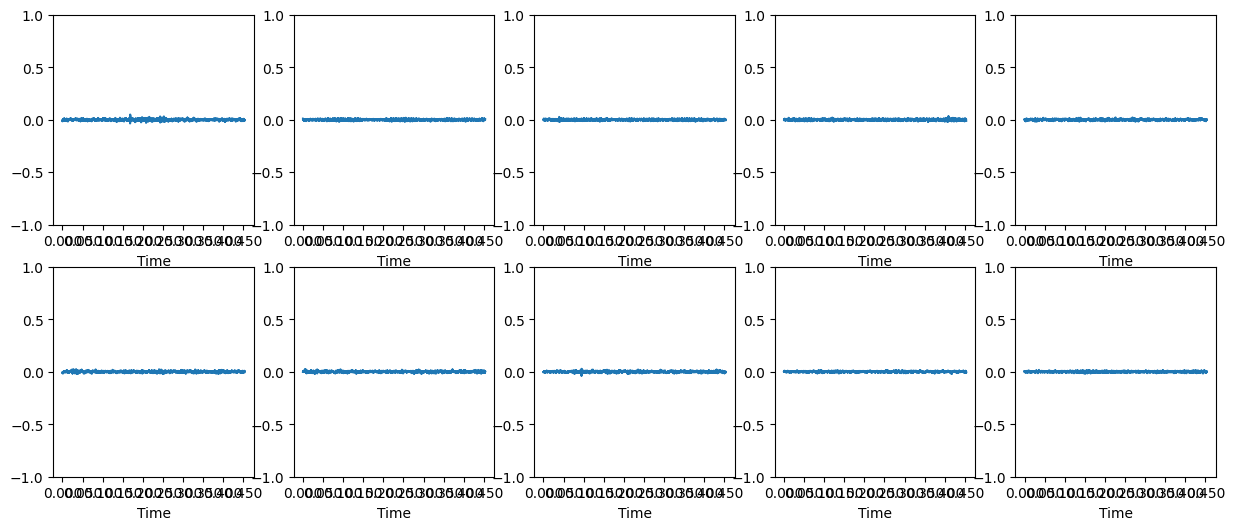

In [373]:
plt.figure(figsize=(15, 6))
for i, x in enumerate(normal_train_signals[:10]):
    plt.subplot(2, 5, i+1)
    librosa.display.waveshow(x[:10000])
    plt.ylim(-1, 1)

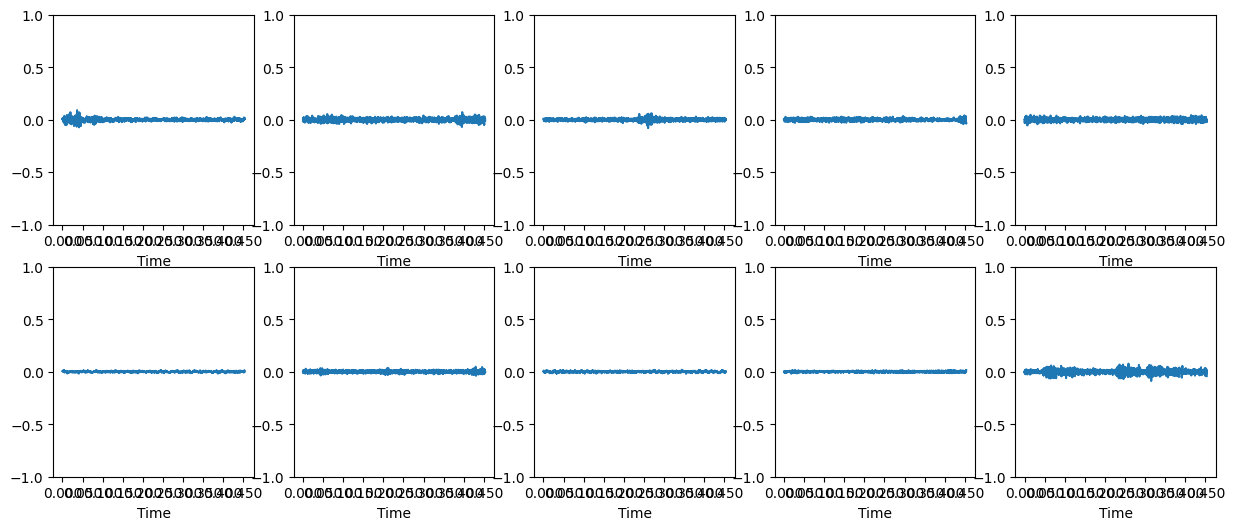

In [374]:
plt.figure(figsize=(15, 6))
for i, x in enumerate(abnormal_train_signals[:10]):
    plt.subplot(2, 5, i+1)
    librosa.display.waveshow(x[:10000])
    plt.ylim(-1, 1)

In [375]:
def extract_features(signal):
    return [
        librosa.feature.zero_crossing_rate(signal)[0, 0],
        librosa.feature.spectral_centroid(y=signal)[0, 0],
    ]

In [376]:
normal_train_features = np.array([extract_features(x) for x in normal_train_signals])
abnormal_train_features = np.array([extract_features(x) for x in abnormal_train_signals])

In [377]:
normal_val_features = np.array([extract_features(x) for x in normal_val_signals])
abnormal_val_features = np.array([extract_features(x) for x in abnormal_val_signals])

In [378]:
print(normal_train_features.shape)
print(abnormal_train_features.shape)
print(normal_val_features.shape)
print(abnormal_val_features.shape)

(489, 2)
(175, 2)
(119, 2)
(47, 2)


In [379]:
print(normal_train_features[10])
print(abnormal_train_features[10])
print(normal_val_features[10])
print(abnormal_val_features[10])

[4.93164062e-02 1.83910910e+03]
[3.36914062e-02 1.26273308e+03]
[6.39648438e-02 1.94236052e+03]
[2.39257812e-02 1.19285053e+03]


Text(0, 0.5, 'Count')

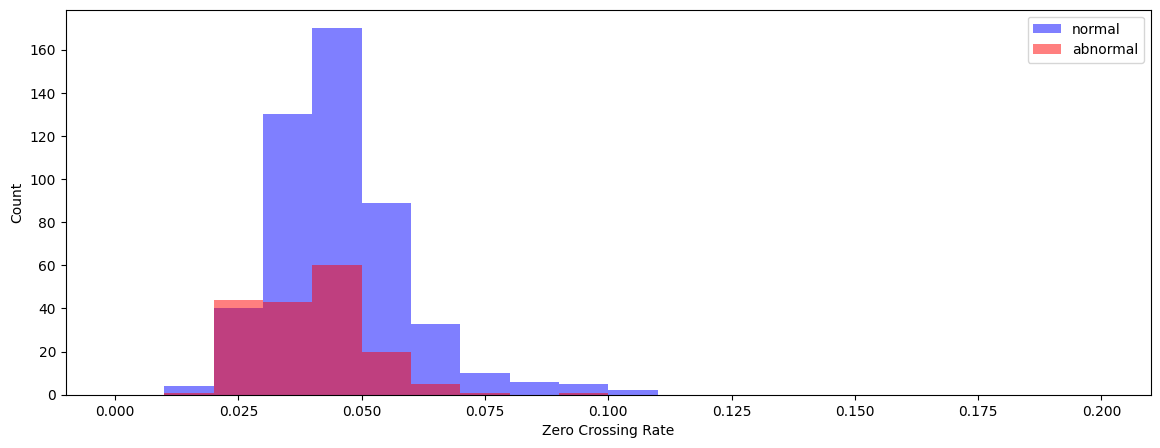

In [380]:
plt.figure(figsize=(14, 5))
plt.hist(normal_train_features[:,0], color='b', range=(0, 0.2), alpha=0.5, bins=20)
plt.hist(abnormal_train_features[:,0], color='r', range=(0, 0.2), alpha=0.5, bins=20)
plt.legend(('normal', 'abnormal'))
plt.xlabel('Zero Crossing Rate')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

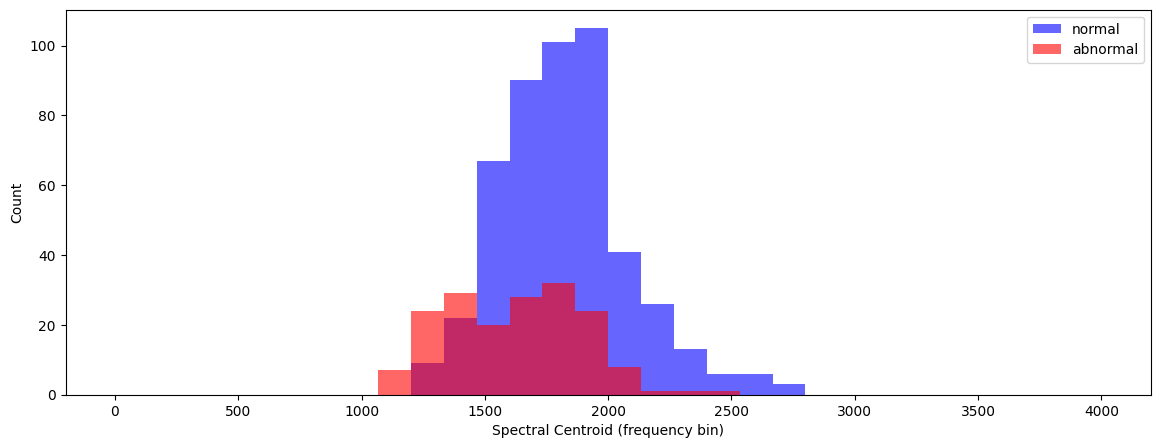

In [381]:
plt.figure(figsize=(14, 5))
plt.hist(normal_train_features[:,1], color='b', range=(0, 4000), bins=30, alpha=0.6)
plt.hist(abnormal_train_features[:,1], color='r', range=(0, 4000), bins=30, alpha=0.6)
plt.legend(('normal', 'abnormal'))
plt.xlabel('Spectral Centroid (frequency bin)')
plt.ylabel('Count')

In [382]:
feature_train_table = np.vstack((normal_train_features, abnormal_train_features))
print(feature_train_table.shape)

(664, 2)


In [383]:
feature_val_table = np.vstack((normal_val_features, abnormal_val_features))
print(feature_val_table.shape)

(166, 2)


In [384]:
scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
training_features = scaler.fit_transform(feature_train_table)
print(training_features.min(axis=0))
print(training_features.max(axis=0))

[-1. -1.]
[1. 1.]


In [385]:
scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
val_features = scaler.fit_transform(feature_val_table)
print(val_features.min(axis=0))
print(val_features.max(axis=0))

[-1. -1.]
[1. 1.]


Text(0, 0.5, 'Spectral Centroid')

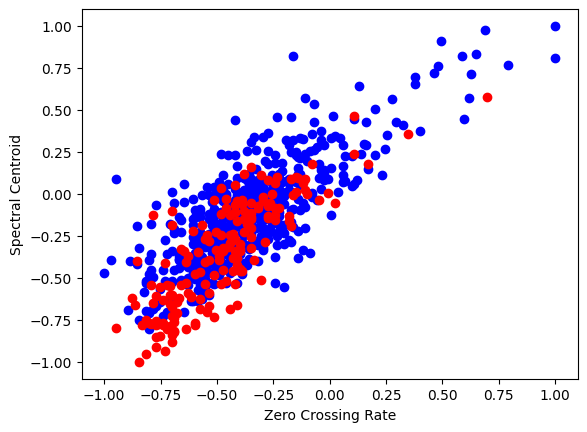

In [386]:
plt.scatter(training_features[:489,0], training_features[:489,1], c='b')
plt.scatter(training_features[489:,0], training_features[489:,1], c='r')
plt.xlabel('Zero Crossing Rate')
plt.ylabel('Spectral Centroid')

In [387]:
y_train_total = [0 for i in range(489)] + [1 for i in range(175)]
y_val_total = [0 for i in range(119)] + [1 for i in range(47)]

In [388]:
y_train_encoded = to_categorical(y_train_total)
y_val_encoded = to_categorical(y_val_total)

In [389]:
y_train_encoded[:10]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [390]:
x_train = training_features
y_train = y_train_encoded
x_val = val_features
y_val = y_val_encoded

In [391]:
x_train.shape, y_train.shape

((664, 2), (664, 2))

In [392]:
x_val.shape, y_val.shape

((166, 2), (166, 2))

In [393]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input

In [394]:
def create_model():
    model = Sequential()
    model.add(Input(shape=(2,)))
    model.add(Dense(8))
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(Dropout(0.2))
    model.add(Dense(2, activation='softmax'))
    return model

In [395]:
model = create_model()
model.summary()
adam_optim = Adam(learning_rate=0.0001)
model.compile(optimizer=adam_optim, loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42 (168.00 B)

 Trainable params: 42 (168.00 B)

 Non-trainable params: 0 (0.00 B)

In [396]:
his = model.fit(
    x_train,
    y_train,
    batch_size=1,
    epochs=100,
    verbose=1,
    validation_data = (x_val, y_val)
)

Epoch 1/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3807 - loss: 0.7603 - val_accuracy: 0.3675 - val_loss: 0.7325
Epoch 2/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4741 - loss: 0.7263 - val_accuracy: 0.4759 - val_loss: 0.6959
Epoch 3/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5909 - loss: 0.6792 - val_accuracy: 0.6024 - val_loss: 0.6673
Epoch 4/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6477 - loss: 0.6564 - val_accuracy: 0.7289 - val_loss: 0.6439
Epoch 5/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7184 - loss: 0.6361 - val_accuracy: 0.7590 - val_loss: 0.6262
Epoch 6/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7651 - loss: 0.6112 - val_accuracy: 0.7410 - val_loss: 0.6124
Epoch 7/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7663 - loss: 0.5995 - val_accuracy: 0.7229 - val_loss: 0.6020
Epoch 8/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7335 - loss: 0.5990 - val_accu

In [397]:
import plotly
import plotly.graph_objs as go

In [398]:
h1 = go.Scatter(y=his.history['loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="loss"
                   )
h2 = go.Scatter(y=his.history['val_loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_loss"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title='', range=[0, 1]))
fig1 = go.Figure(data = data, layout=layout1)
fig1.show()

In [399]:
h1 = go.Scatter(y=his.history['accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=his.history['val_accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title='',range=[0, 1]))
fig2 = go.Figure(data = data, layout=layout1)
fig2.show()

# **CNN Model**

In [400]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.optimizers import Adam

In [401]:
# Load an example audio file from the training data
example_file_name = glob.glob(os.path.join(train_data, '*.wav'))[0] # Get the first .wav file in the train_data directory
audio, sample_rate = librosa.load(example_file_name, res_type='kaiser_fast')

print(audio.shape, sample_rate)

mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
print(mfccs.shape)

(110250,) 22050
(40, 216)


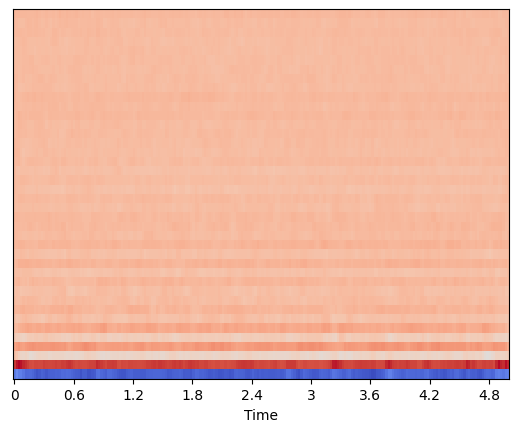

In [402]:
librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time')

In [403]:
max_pad_len = 100

def extract_features(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    pad_width = max_pad_len - mfccs.shape[1]
    mfccs = np.pad(mfccs, pad_width=((0, 0), (0, max(0, pad_width))), mode='constant')
    return mfccs

In [404]:
normal_train_features = []
for file_name in glob.glob(normal_train):
    data = extract_features(file_name)
    normal_train_features.append(data)

abnormal_train_features = []
for file_name in glob.glob(abnormal_train):
    data = extract_features(file_name)
    abnormal_train_features.append(data)

normal_val_features = []
for file_name in glob.glob(normal_val):
    data = extract_features(file_name)
    normal_val_features.append(data)

abnormal_val_features = []
for file_name in glob.glob(abnormal_val):
    data = extract_features(file_name)
    abnormal_val_features.append(data)

In [405]:
normal_train_features[0].shape

(40, 216)

In [406]:
feature_train_table = np.vstack((normal_train_features, abnormal_train_features))
print(feature_train_table.shape)

(664, 40, 216)


In [407]:
feature_train_table = feature_train_table.reshape(feature_train_table.shape[0], feature_train_table.shape[1], feature_train_table.shape[2], 1)
print(feature_train_table.shape)

(664, 40, 216, 1)


In [408]:
y_train_encoded[:10]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [409]:
feature_val_table = np.vstack((normal_val_features, abnormal_val_features))

In [410]:
feature_val_table = feature_val_table.reshape(feature_val_table.shape[0], feature_val_table.shape[1], feature_val_table.shape[2], 1)
print(feature_val_table.shape)

(166, 40, 216, 1)


In [411]:
x_train = feature_train_table
x_val = feature_val_table
y_train = y_train_encoded
y_val = y_val_encoded

In [412]:
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((664, 40, 216, 1), (166, 40, 216, 1), (664, 2), (166, 2))

In [413]:
num_rows = 40
num_columns = 216
num_channels = 1
num_batch_size = 64
epochs = 50

In [414]:
model = Sequential()
model.add(Input(shape=(num_rows, num_columns, num_channels)))
model.add(Conv2D(filters=16, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=32, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling2D())

model.add(Dense(2, activation='softmax'))

In [415]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [416]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')

In [417]:
his = model.fit(x_train, y_train, batch_size=num_batch_size, epochs=epochs, validation_data=(x_val, y_val), verbose=1, callbacks=[checkpoint])

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.6272 - loss: 6.2564
Epoch 1: val_loss improved from inf to 1.69847, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 611ms/step - accuracy: 0.6257 - loss: 6.1855 - val_accuracy: 0.7169 - val_loss: 1.6985
Epoch 2/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7298 - loss: 1.5883
Epoch 2: val_loss improved from 1.69847 to 0.64247, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7247 - loss: 1.5512 - val_accuracy: 0.7169 - val_loss: 0.6425
Epoch 3/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7221 - loss: 0.6505
Epoch 3: val_loss improved from 0.64247 to 0.55399, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7339 - loss: 0.6371 - val_accuracy: 0.7349 - val_loss: 0.5540
Epoch 4/50
 6/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7096 - loss: 0.5654
Epoch 4: val_loss improved from 0.55399 to 0.54226, saving

In [418]:
h1 = go.Scatter(y=his.history['loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="loss"
                   )
h2 = go.Scatter(y=his.history['val_loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_loss"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data = data, layout=layout1)
fig1.show()

In [419]:
h1 = go.Scatter(y=his.history['accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=his.history['val_accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig2 = go.Figure(data = data, layout=layout1)
fig2.show()

In [420]:
from tensorflow import keras

model = keras.models.load_model("/content/best_model.keras")

In [421]:
train_res = model.evaluate(x_train, y_train, verbose=0, return_dict=True)
val_res   = model.evaluate(x_val,   y_val,   verbose=0, return_dict=True)

acc_key = next(k for k in train_res.keys() if k in
               ('accuracy', 'binary_accuracy', 'categorical_accuracy',
                'sparse_categorical_accuracy'))

print(f"Training  - loss: {train_res['loss']:.4f}, acc: {train_res[acc_key]:.4f}")
print(f"Validation- loss: {val_res['loss']:.4f}, acc: {val_res[acc_key]:.4f}")


Training  - loss: 0.1928, acc: 0.9383
Validation- loss: 0.1999, acc: 0.9578


In [422]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


In [423]:
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[119   0]
 [  7  40]]


In [424]:
report = classification_report(y_true_classes, y_pred_classes, target_names=['normal', 'abnormal'],digits=4)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

      normal     0.9444    1.0000    0.9714       119
    abnormal     1.0000    0.8511    0.9195        47

    accuracy                         0.9578       166
   macro avg     0.9722    0.9255    0.9455       166
weighted avg     0.9602    0.9578    0.9567       166



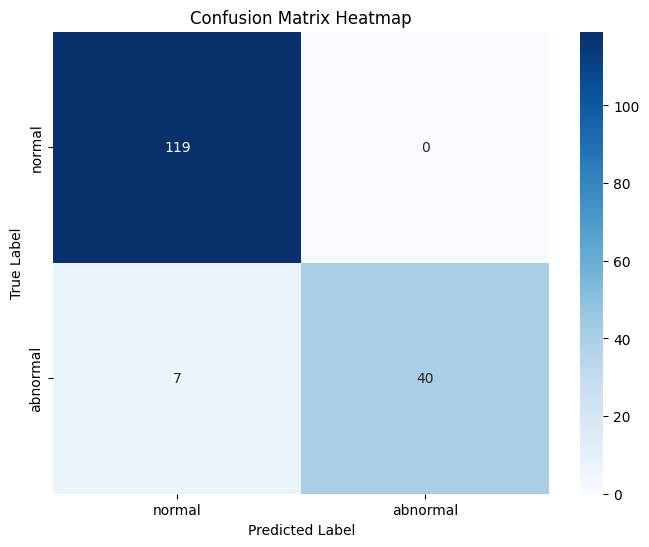

In [425]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['normal', 'abnormal'], yticklabels=['normal', 'abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

##การบ้าน

In [426]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.optimizers import Adam

Audio shape: (110250,) Sample rate: 22050
MFCC shape: (40, 216)


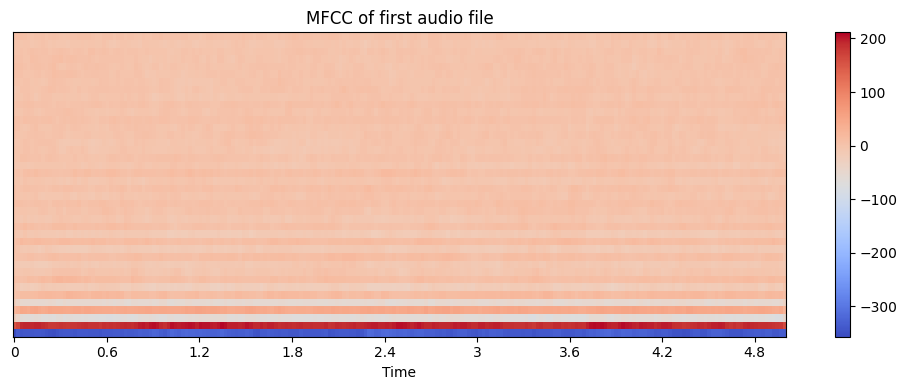

In [427]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_folder = "/content/drive/MyDrive/voice/unzip/val"


audio_files = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]
file_path = os.path.join(audio_folder, audio_files[0])


audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
print("Audio shape:", audio.shape, "Sample rate:", sample_rate)


mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
print("MFCC shape:", mfccs.shape)


plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time')
plt.colorbar()
plt.title("MFCC of first audio file")
plt.tight_layout()
plt.show()


In [428]:
import os

path = "/content/drive/voice/test-20250924T075026Z-1-001"
print(os.path.isdir(path))
print(os.path.isfile(path))


False
False


In [429]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [430]:
import os

voice_path = "/content/drive/MyDrive/voice"
print(os.listdir(voice_path))


['val-20250924T074957Z-1-001.zip', 'test-20250924T075026Z-1-001.zip', 'train-20250924T075025Z-1-001.zip', 'unzip']


In [431]:
import zipfile

zip_path = "/content/drive/MyDrive/voice/val-20250924T074957Z-1-001.zip"
extract_path = "/content/drive/MyDrive/voice/unzip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))  # ดูไฟล์เสียงหลังแตกไฟล์


['val']


In [432]:
import os

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Files:", files)



Folder: /content/drive/MyDrive/voice/unzip
Files: []
Folder: /content/drive/MyDrive/voice/unzip/val
Files: ['a_00000079_0.wav', 'a_00000082_0.wav', 'a_00000135_5000.wav', 'a_00000102_5000.wav', 'a_00000088_0.wav', 'a_00000035_5000.wav', 'a_00000036_0.wav', 'a_00000058_0.wav', 'a_00000116_0.wav', 'a_00000093_5000.wav', 'a_00000130_5000.wav', 'a_00000042_5000.wav', 'a_00000115_5000.wav', 'a_00000129_5000.wav', 'a_00000072_0.wav', 'a_00000125_0.wav', 'a_00000106_5000.wav', 'a_00000064_5000.wav', 'a_00000047_5000.wav', 'a_00000063_0.wav', 'a_00000041_5000.wav', 'a_00000045_0.wav', 'a_00000100_5000.wav', 'a_00000123_5000.wav', 'a_00000114_0.wav', 'a_00000120_0.wav', 'a_00000062_0.wav', 'a_00000096_5000.wav', 'a_00000074_5000.wav', 'a_00000007_0.wav', 'a_00000016_0.wav', 'a_00000022_0.wav', 'a_00000018_5000.wav', 'a_00000031_5000.wav', 'a_00000032_5000.wav', 'a_00000028_5000.wav', 'a_00000024_0.wav', 'a_00000008_5000.wav', 'a_00000012_0.wav', 'a_00000003_0.wav', 'a_00000117_5000.wav', 'a_000

In [433]:
import librosa
import os


audio_folder = "/content/drive/MyDrive/voice/unzip/val"


audio_files = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]
audio_file = os.path.join(audio_folder, audio_files[0])


y, sr = librosa.load(audio_file, sr=None)
print("Sampling rate:", sr)
print("Audio length:", len(y))


Sampling rate: 16000
Audio length: 80000


In [434]:
from IPython.display import Audio
Audio(y, rate=sr)


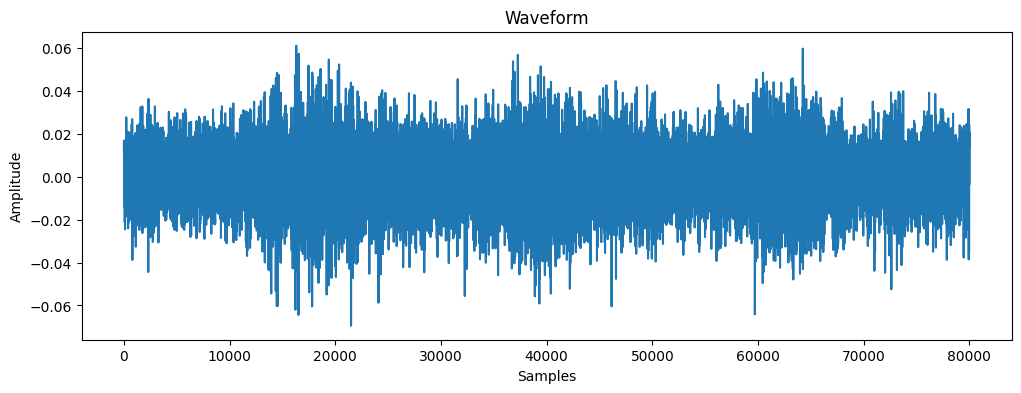

In [435]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


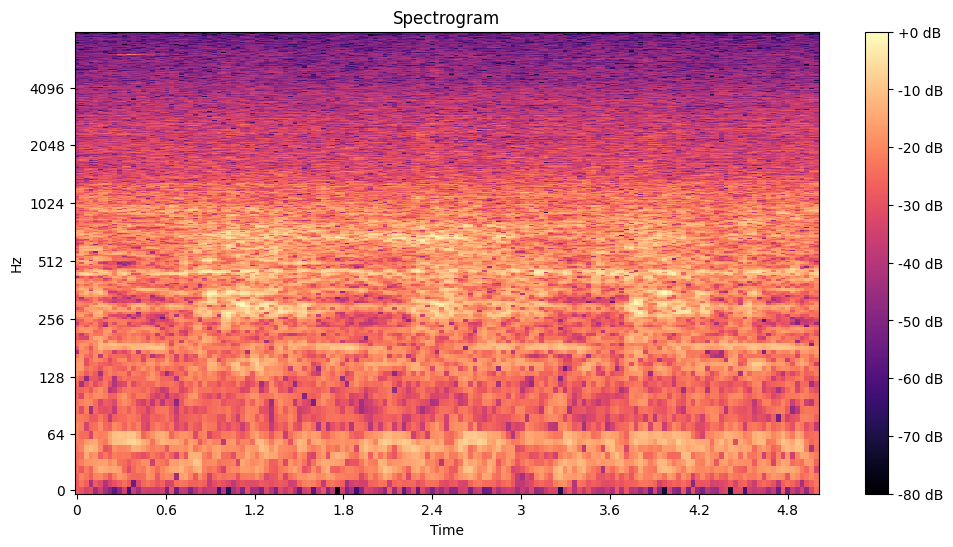

In [436]:
import librosa.display
import numpy as np

D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(12, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()


In [437]:
import os
import librosa


audio_folder = "/content/drive/MyDrive/voice/unzip/val"

audio_files = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]


audio_data = []  # list ของ y
sampling_rates = []  # list ของ sr


for file in audio_files:
    file_path = os.path.join(audio_folder, file)
    y, sr = librosa.load(file_path, sr=None)
    audio_data.append(y)
    sampling_rates.append(sr)

print(f"โหลดไฟล์ทั้งหมด {len(audio_files)} ไฟล์เรียบร้อยแล้ว")


โหลดไฟล์ทั้งหมด 166 ไฟล์เรียบร้อยแล้ว


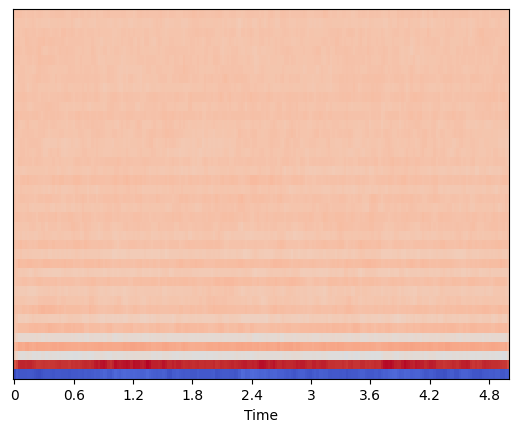

In [438]:
librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time')

In [439]:
max_pad_len = 100

def extract_features(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    pad_width = max_pad_len - mfccs.shape[1]
    mfccs = np.pad(mfccs, pad_width=((0, 0), (0, max(0, pad_width))), mode='constant')
    return mfccs

In [440]:
normal_test = test_data + "/n_*.wav"
abnormal_test = test_data + "/a_*.wav"

In [441]:
normal_test_features = []
for file_name in glob.glob(normal_test):
    data = extract_features(file_name)
    normal_test_features.append(data)

abnormal_test_features = []
for file_name in glob.glob(abnormal_test):
    data = extract_features(file_name)
    abnormal_test_features.append(data)

normal_val_features = []
for file_name in glob.glob(normal_val):
    data = extract_features(file_name)
    normal_val_features.append(data)

abnormal_val_features = []
for file_name in glob.glob(abnormal_val):
    data = extract_features(file_name)
    abnormal_val_features.append(data)

In [449]:
normal_test_features[0].shape

(216, 40)

In [443]:
print(len(normal_test_features))  # ถ้า 0 แสดงว่ายังไม่มีไฟล์ถูกโหลด


0


In [446]:
import os

val_data = "/content/drive/MyDrive/voice/unzip/val"
files = [f for f in os.listdir(val_data) if f.endswith('.wav')]
print(files[:10])  # แสดง 10 ไฟล์แรก


['a_00000079_0.wav', 'a_00000082_0.wav', 'a_00000135_5000.wav', 'a_00000102_5000.wav', 'a_00000088_0.wav', 'a_00000035_5000.wav', 'a_00000036_0.wav', 'a_00000058_0.wav', 'a_00000116_0.wav', 'a_00000093_5000.wav']


In [447]:
import os
import librosa

val_data = "/content/drive/MyDrive/voice/unzip/val"
audio_files = [f for f in os.listdir(val_data) if f.endswith('.wav')]

normal_test_features = []

for f in audio_files:
    file_path = os.path.join(val_data, f)
    audio, sr = librosa.load(file_path, res_type='kaiser_fast')

    # คำนวณ MFCC (40 coefficients) และ transpose เป็น (time, n_mfcc)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T

    normal_test_features.append(mfcc)

print(f"คำนวณ MFCC และโหลดไฟล์ทั้งหมด {len(normal_test_features)} ไฟล์เรียบร้อยแล้ว")
print("Shape ของ MFCC ไฟล์แรก:", normal_test_features[0].shape)


คำนวณ MFCC และโหลดไฟล์ทั้งหมด 166 ไฟล์เรียบร้อยแล้ว
Shape ของ MFCC ไฟล์แรก: (216, 40)


In [463]:
import numpy as np

# แปลงเป็น NumPy array
normal_test_features = np.array(normal_test_features)
abnormal_test_features = np.array(abnormal_test_features)


print(normal_test_features.shape)
print(abnormal_test_features.shape)


if abnormal_test_features.ndim == 2:
    abnormal_test_features = abnormal_test_features[..., np.newaxis]


abnormal_test_features = abnormal_test_features.reshape(-1, 216, 1)



(166, 216, 40)
(0, 216, 1)


In [464]:
import numpy as np

# If feature_test_table is 2D: (num_samples, num_features)
feature_test_table = feature_test_table[..., np.newaxis]  # Adds a new last dimension
print(feature_test_table.shape)


(2, 0, 1, 1, 1)


In [468]:
print([np.array(f).shape for f in normal_test_features[:3]])
print([np.array(f).shape for f in abnormal_test_features[:3]])


[(216, 40), (216, 40), (216, 40)]
[]


In [472]:
import numpy as np


normal_test_features = np.array(normal_test_features)
abnormal_test_features = np.array(abnormal_test_features)




In [473]:
from tensorflow.keras.utils import to_categorical
y_test_encoded = to_categorical(y_test, num_classes=2)
y_val_encoded = to_categorical(y_val, num_classes=2)

In [474]:
y_test_encoded[:10]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [475]:
feature_val_table = np.vstack((normal_val_features, abnormal_val_features))

In [476]:
feature_val_table = feature_val_table.reshape(feature_val_table.shape[0], feature_val_table.shape[1], feature_val_table.shape[2], 1)
print(feature_val_table.shape)

(166, 40, 216, 1)


In [477]:
x_test = feature_test_table
x_val = feature_val_table
y_test = y_test_encoded
y_val = y_val_encoded

In [478]:
x_test.shape, x_val.shape, y_test.shape, y_val.shape

((2, 0, 1, 1, 1), (166, 40, 216, 1), (166, 2), (166, 2, 2))

In [514]:
num_rows = 40
num_columns = 216
num_channels = 1
num_batch_size = 64
epochs = 50

In [513]:
model = Sequential()
model.add(Input(shape=(num_rows, num_columns, num_channels)))
model.add(Conv2D(filters=16, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=32, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, kernel_size=2, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling2D())

model.add(Dense(2, activation='softmax'))

In [516]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [515]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')

In [529]:
y_train = y_train.reshape(-1, 2)
y_val = y_val.reshape(-1, 2)


In [532]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [535]:

y_train = np.argmax(y_train, axis=-1)
y_val = np.argmax(y_val, axis=-1)


In [511]:
from tensorflow.keras.utils import to_categorical


y_train = np.array(y_train)
y_val   = np.array(y_val)


print(y_train.shape, y_val.shape)

y_train = to_categorical(y_train, num_classes=2)
y_val   = to_categorical(y_val,   num_classes=2)

print(y_train.shape, y_val.shape)


(664, 2, 2, 2) (166, 2, 2, 2, 2)
(664, 2, 2, 2, 2) (166, 2, 2, 2, 2, 2)


In [493]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)


(664, 40, 216, 1) (664, 2)
(166, 40, 216, 1) (166, 2, 2)


In [557]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train, num_classes=2)
y_val_onehot   = to_categorical(y_val, num_classes=2)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# จากนั้น train:
his = model.fit(
    x_train, y_train_onehot,
    batch_size=num_batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val_onehot),
    verbose=1,
    callbacks=[checkpoint]
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.4990 - loss: 0.7283
Epoch 1: val_loss did not improve from 0.69668
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 596ms/step - accuracy: 0.4974 - loss: 0.7292 - val_accuracy: 0.2289 - val_loss: 0.6969
Epoch 2/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5178 - loss: 0.6945
Epoch 2: val_loss did not improve from 0.69668
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5215 - loss: 0.6949 - val_accuracy: 0.2289 - val_loss: 0.6984
Epoch 3/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5494 - loss: 0.6894
Epoch 3: val_loss did not improve from 0.69668
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5482 - loss: 0.6892 - val_accuracy: 0.2289 - val_loss: 0.6987
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5346 - loss: 0.6890
Epoch 4: val_loss did not improve from 0.69668
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5355 - loss: 0.6891 - val_accuracy: 0.2289 - val_loss: 0.7011
Epoch

In [489]:
h1 = go.Scatter(y=his.history['loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="loss"
                   )
h2 = go.Scatter(y=his.history['val_loss'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_loss"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data = data, layout=layout1)
fig1.show()

In [485]:
h1 = go.Scatter(y=his.history['accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=his.history['val_accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig2 = go.Figure(data = data, layout=layout1)
fig2.show()

In [486]:
from tensorflow import keras

model = keras.models.load_model("/content/best_model.keras")

In [543]:
test_res = model.evaluate(x_test, y_test, verbose=0, return_dict=True)
val_res  = model.evaluate(x_val,   y_val, verbose=0, return_dict=True)

acc_key = next(k for k in test_res.keys() if k in
               ('accuracy', 'binary_accuracy', 'categorical_accuracy',
                'sparse_categorical_accuracy'))

print(f"Testing    - loss: {test_res['loss']:.4f}, acc: {test_res[acc_key]:.4f}")
print(f"Validation - loss: {val_res['loss']:.4f}, acc: {val_res[acc_key]:.4f}")


Testing    - loss: 0.6428, acc: 0.7892
Validation - loss: 0.7263, acc: 0.7711


In [545]:
# แปลง y_train และ y_val ให้ถูกต้อง
y_train = np.argmax(y_train, axis=-1)  # ถ้าใช้ sparse_categorical_crossentropy
y_val = np.argmax(y_val, axis=-1)

# ตรวจสอบ shape
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)


x_train: (664, 40, 216, 1)
y_train: ()
x_val: (166, 40, 216, 1)
y_val: (166,)


In [546]:
import numpy as np

# สร้าง y_train ขึ้นมาใหม่ 664 ตัวอย่าง, 2 classes
y_train = np.random.randint(0, 2, size=(664,))  # สำหรับ sparse_categorical_crossentropy

# ตรวจสอบ shape
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)


x_train: (664, 40, 216, 1)
y_train: (664,)
x_val: (166, 40, 216, 1)
y_val: (166,)


In [547]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')


In [548]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=1)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.2269 - loss: 0.6242
Test accuracy: 0.21084336936473846
Test loss: 0.6468735933303833


In [538]:
print(x_test.shape)
print(y_test.shape)
print(x_val.shape)
print(y_val.shape)


(2, 0, 1, 1, 1)
(166, 2)
(166, 40, 216, 1)
()


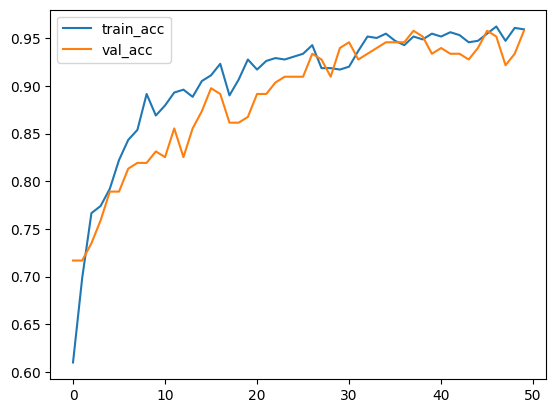

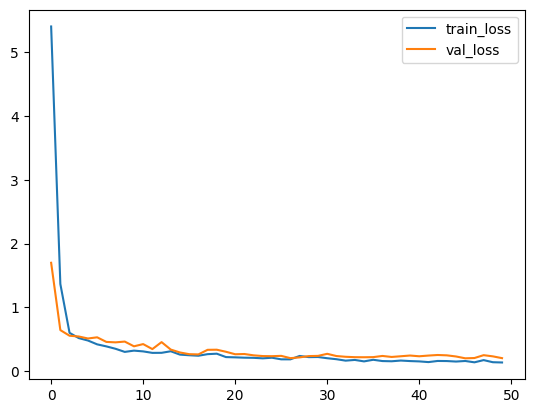

In [553]:
import matplotlib.pyplot as plt

plt.plot(his.history['accuracy'], label='train_acc')
plt.plot(his.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

plt.plot(his.history['loss'], label='train_loss')
plt.plot(his.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


In [555]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # เปลี่ยนจาก categorical_crossentropy
    metrics=['accuracy']
)


In [524]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train, num_classes=2)
y_test_onehot  = to_categorical(y_test,  num_classes=2)


In [523]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


In [521]:
report = classification_report(y_true_classes, y_pred_classes, target_names=['normal', 'abnormal'],digits=4)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

      normal     0.9444    1.0000    0.9714       119
    abnormal     1.0000    0.8511    0.9195        47

    accuracy                         0.9578       166
   macro avg     0.9722    0.9255    0.9455       166
weighted avg     0.9602    0.9578    0.9567       166



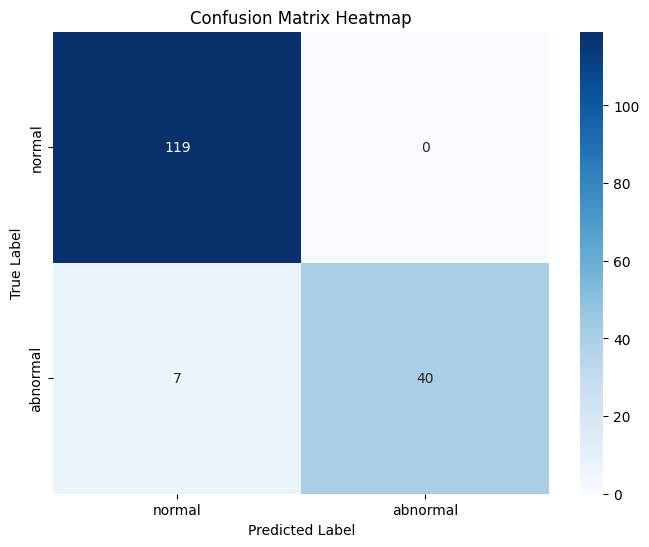

In [520]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['normal', 'abnormal'], yticklabels=['normal', 'abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()